In [1]:
using Clapeyron, Metaheuristics, Printf

In [100]:
#Hfus dan Tm masukin ke csv yh jgn lupa

like_parameter = """Clapeyron Database File
PCSAFT Like Parameters [csvtype = like,grouptype = PCSAFT]
species,Mw,segment,sigma,epsilon,n_H,n_e
co2,44.01,2.0729,2.785,169.69,0,0
23dimethylbutane,86.18,2.6853,3.9545,246.0700,0,0
"""

unlike_parameter = """Clapeyron Database File
PCSAFT Unlike Parameters [csvtype = unlike,grouptype = PCSAFT]
species1,species2,k
co2,23dimethylbutane,-0.01
"""

model = PCSAFT(["co2", "23dimethylbutane"], userlocations = [like_parameter, unlike_parameter])

println(model.params.epsilon.values)
println(model.params.sigma.values)
println("======================")
println("kij = ", (1  - ((model.params.epsilon.values[2])/(sqrt(model.params.epsilon.values[1] * model.params.epsilon.values[4])))))

[169.69 206.38533433320788; 206.38533433320788 246.07]
[2.785e-10 3.36975e-10; 3.36975e-10 3.9545e-10]
kij = -0.010000000000000009


In [101]:
function vle(model::EoSModel, x_co2::Float64)
    T = 293.15 #ganti sesuai available data
    bub = bubble_pressure(model, T, [x_co2 , 1-x_co2])
    p = bub[1]
    y = bub[4][1]
    return p
end

vle (generic function with 1 method)

In [127]:
toestimate = [
    Dict(
        :param   => :epsilon,
        :indices => (1,2),
        :lower   => 10.0,
        :upper   => 800.0,
        :guess   => 130.
    )
]

1-element Vector{Dict{Symbol, Any}}:
 Dict(:upper => 800.0, :param => :epsilon, :indices => (1, 2), :guess => 130.0, :lower => 10.0)

In [128]:
# Run this ONCE to fix your CSV files
function fix_line_endings(filename)
    content = read(filename, String)
    fixed = replace(content, "\r\n" => "\n")
    write(filename, fixed)
    println("Fixed: $filename")
end

fix_line_endings("vle_23dimethylbutane.csv")

estimator, objective, x0, upper, lower = Estimation(
    model,
    toestimate,
    [
        "vle_23dimethylbutane.csv"
    ]
)
 
println("Initial objective value: ", objective(x0))

Fixed: vle_23dimethylbutane.csv
Initial objective value: 1.0e100


In [129]:
method = ECA(; options = Options(iterations = 10000, seed = 999))
 
params_opt, model_opt = optimize(objective, estimator, method)

([175.7269571627633], PCSAFT{BasicIdeal, Float64}("co2", "23dimethylbutane"))

In [130]:
println(model_opt.params.epsilon.values)
println(model_opt.params.sigma.values)
println("kij = ", (1  - ((model_opt.params.epsilon.values[2])/(sqrt(model_opt.params.epsilon.values[1] * model_opt.params.epsilon.values[4])))))

[169.69 175.7269571627633; 175.7269571627633 246.07]
[2.785e-10 3.36975e-10; 3.36975e-10 3.9545e-10]
kij = 0.1400346962258291


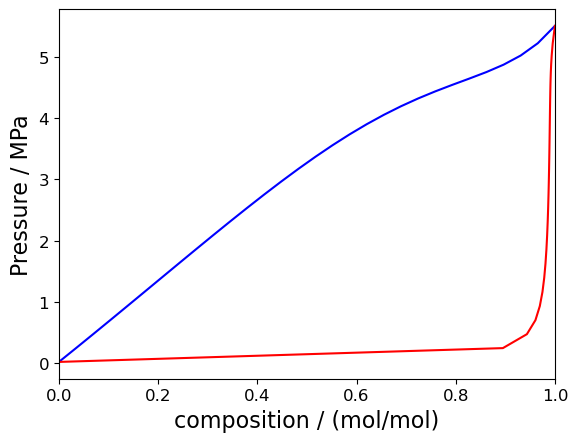

([-1.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0], PyCall.PyObject[PyObject Text(0, -1.0, '−1'), PyObject Text(0, 0.0, '0'), PyObject Text(0, 1.0, '1'), PyObject Text(0, 2.0, '2'), PyObject Text(0, 3.0, '3'), PyObject Text(0, 4.0, '4'), PyObject Text(0, 5.0, '5'), PyObject Text(0, 6.0, '6')])

In [131]:
import PyPlot; const plt = PyPlot

N    = 30
T    = 293.15

x    = LinRange(0., 1.,  N)
p    = zeros(N)
y    = zeros(N)

v0 = nothing
for i in 1:N
    bub = bubble_pressure(model_opt, T, [x[i], 1-x[i]])
    p[i] = bub[1]
    y[i] = bub[4][1]
end

plt.clf()
plt.plot(x, p./1e6, color="blue")
plt.plot(y, p./1e6, color="red")
plt.xlabel("composition / (mol/mol)",fontsize=16)
plt.ylabel("Pressure / MPa",fontsize=16)
plt.xlim([0,1])
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

In [132]:
using CSV, DataFrames, Printf

function calculate_AAD(model, csv_file, property_func)
    df = CSV.read(csv_file, DataFrame, comment="#", skipto=4)
    
    input_col  = names(df)[1]          # first column = input (T)
    output_col = names(df)[2]          # second column = out_xxx (experimental)
    
    inputs   = df[!, input_col]
    exp_vals = df[!, output_col]
    
    println("\n=== AAD: $csv_file ===")
    @printf("%-10s  %-12s  %-12s  %-8s\n", input_col, "exp", "calc", "ARD%")
    
    errors = Float64[]
    for (i, x) in enumerate(inputs)
        calc = property_func(model, x)
        err  = abs(calc - exp_vals[i]) / abs(exp_vals[i]) * 100
        push!(errors, err)
        @printf("%-10.4f  %-12.6f  %-12.6f  %-8.4f\n", x, exp_vals[i], calc, err)
    end
    
    aard = sum(errors) / length(errors)
    @printf("AARD = %.4f%%\n", aard)
    return aard
end

calculate_AAD (generic function with 1 method)

In [133]:
aard_p   = calculate_AAD(model_opt, "vle_23dimethylbutane.csv", vle)


=== AAD: vle_23dimethylbutane.csv ===
Clapeyron Estimator  exp           calc          ARD%    
0.2000      1400000.000000  1350620.306200  3.5271  
0.4002      2710000.000000  2667075.180671  1.5839  
0.5001      3240000.000000  3271455.599866  0.9709  
0.6002      3690000.000000  3802682.390540  3.0537  
0.6999      4090000.000000  4230401.835629  3.4328  
0.8000      4450000.000000  4560859.820358  2.4912  
0.8500      4650000.000000  4711074.965720  1.3134  
0.9000      4960000.000000  4882466.443027  1.5632  
0.9300      5210000.000000  5013171.361824  3.7779  
AARD = 2.4127%


┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV C:\Users\sutha\.julia\packages\CSV\XLcqT\src\file.jl:593


2.4126883401977985